# Compute and analyze prediction metrics for hurricane track.
author: Elizabeth A. Barnes and Randal J. Barnes

In [1]:
import sys
sys.path.append('..')

import datetime
import importlib as imp
import os
import pickle
import pprint
import random
import time

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

import tensorflow_probability as tfp
from sklearn import preprocessing
from silence_tensorflow import silence_tensorflow

from build_data import build_hurricane_data
import build_model
import experiment_settings
from save_model_run import save_model_run

from scipy.stats import multivariate_normal
import mahalanobis
import prediction_metrics
import pandas as pd
import seaborn as sns
import cmasher as cmr

mpl.rcParams["figure.facecolor"] = "white"
np.warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)
dpiFig = 300.

In [2]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "08 August 2022"

silence_tensorflow()
tf.config.set_visible_devices([], 'GPU') # turn-off tensorflow-metal if it is on

DATA_PATH = "../data/"
MODEL_PATH = "saved_models/"
METRIC_PATH = "saved_predictions/"
FIGURE_PATH = "figures/analysis_plots/"
OVERWRITE_METRICS = False

In [3]:
EXP_NAME_LIST = (
    "bivariate_normal_101_EPCP24",
    "bivariate_normal_102_EPCP48",
    "bivariate_normal_103_EPCP72",
    "bivariate_normal_104_EPCP96",
    "bivariate_normal_105_EPCP120",    
    
    "bivariate_normal_201_AL24",
    "bivariate_normal_202_AL48",
    "bivariate_normal_203_AL72",
    "bivariate_normal_204_AL96",
    "bivariate_normal_205_AL120",       
)

# Get metrics

In [4]:
def get_metrics(model, x_data, onehot_data):

    y_data = model.predict(x_data)
    rmse, rmse_cons = prediction_metrics.get_errors(y_data, onehot_data)
    bins, pit_hist, D, EDp = prediction_metrics.compute_pit(y_data, onehot_data)
    
    # write metrics dictionary and return
    metrics_dict = {
        'pit_D': D,
        'pit_EDp': EDp,

        'cons_error': rmse_cons.mean(),
        'mean_error': rmse.mean(),

        'mean_error_reduction': rmse_cons.mean() - rmse.mean(),
        'perc_error_reduction': 100.*(rmse_cons.mean() - rmse.mean())/rmse_cons.mean(),
    }
    
    return metrics_dict

def get_best_validation(df):

    print("**plotting only the best seed for validation error reductions**")
    idx = df.groupby(['exp_name', 'testing_years'], sort=False)['mean_error_reduction_val'].transform(max) == df['mean_error_reduction_val']

    return df[idx]


In [5]:
for EXP_NAME in EXP_NAME_LIST:
    print('----' + EXP_NAME + '----')
    
    for TESTING_YEAR in np.arange(2013,2022):
        # print(TESTING_YEAR)
        
        for RNG_SEED in (123, 234, 345):
            settings = experiment_settings.get_settings(EXP_NAME)

            network_seed = RNG_SEED
            settings['rng_seed'] = RNG_SEED
            settings["years_test"] = (TESTING_YEAR,)
            
            # get model name
            model_name = (
                EXP_NAME + "_" + 
                str(TESTING_YEAR) + '_' +
                settings["uncertainty_type"] + '_' + 
                f"network_seed_{network_seed}_rng_seed_{settings['rng_seed']}"
            )
            
            # check if metrics exist
            metric_filename = METRIC_PATH + model_name + '_metrics.pickle'              
            if (os.path.exists(metric_filename) and OVERWRITE_METRICS==False):
                # print(metric_filename + ' exists. Skipping...')
                continue
                
            # get the data
            (
                data_summary,        
                x_train,
                onehot_train,
                x_val,
                onehot_val,
                x_test,
                onehot_test,        
                x_valtest,
                onehot_valtest,
                df_train,
                df_val,
                df_test,
                df_valtest,
            ) = build_hurricane_data(DATA_PATH, settings, verbose=0)

            # load the model
            try:
                model = tf.keras.models.load_model(MODEL_PATH + model_name + "_model", compile=False)
            except:
                break

            
            # make the predictions and put into dictionary            
            metrics_test = get_metrics(model, x_test, onehot_test)
            metrics_val = get_metrics(model, x_val, onehot_val)                                    
            metrics_valtest = get_metrics(model, x_valtest, onehot_valtest)            
            
            # create the metrics dataframe
            d = {}
            d['uncertainty_type'] = settings["uncertainty_type"]
            d['network_seed'] = network_seed
            d['rng_seed'] = settings['rng_seed']
            d['exp_name'] = EXP_NAME
            d['basin_lead'] = EXP_NAME[EXP_NAME.rfind('_')+1:]
            d['testing_years'] = settings["years_test"]
            
            for k in metrics_test.keys():
                k_key = k + '_test'            
                d[k_key] = metrics_test[k]
            for k in metrics_val.keys():
                k_key = k + '_val'
                d[k_key] = metrics_val[k]
            for k in metrics_valtest.keys():
                k_key = k + '_valtest'
                d[k_key] = metrics_valtest[k]

            # save the dataframe    
            # pprint.pprint(d, width=80)  
            df = pd.DataFrame(data=d, index=[0])
            df.to_pickle(metric_filename)
            

----bivariate_normal_101_EPCP24----
----bivariate_normal_102_EPCP48----
----bivariate_normal_103_EPCP72----
----bivariate_normal_104_EPCP96----
----bivariate_normal_105_EPCP120----
----bivariate_normal_201_AL24----
----bivariate_normal_202_AL48----
----bivariate_normal_203_AL72----
----bivariate_normal_204_AL96----
----bivariate_normal_205_AL120----


# Plot metric results

In [6]:
N_COLORS = 50
colors = ('#D95980','#284E60','#284E60','#C3B1E1','#351F27','#A9C961')

### for white background...
plt.rc('text',usetex=True)
plt.rc('font',**{'family':'sans-serif','sans-serif':['Avant Garde']}) 
plt.rc('savefig',facecolor='white')
plt.rc('axes',facecolor='white')
plt.rc('axes',labelcolor='dimgrey')
plt.rc('axes',labelcolor='dimgrey')
plt.rc('xtick',color='dimgrey')
plt.rc('ytick',color='dimgrey')
################################  
################################  
def adjust_spines(ax, spines):
    for loc, spine in ax.spines.items():
        if loc in spines:
            spine.set_position(('outward', 5))
        else:
            spine.set_color('none')  
    if 'left' in spines:
        ax.yaxis.set_ticks_position('left')
    else:
        ax.yaxis.set_ticks([])
    if 'bottom' in spines:
        ax.xaxis.set_ticks_position('bottom')
    else:
            ax.xaxis.set_ticks([]) 
            
def format_spines(ax):
    adjust_spines(ax, ['left', 'bottom'])
    ax.spines['top'].set_color('none')
    ax.spines['right'].set_color('none')
    ax.spines['left'].set_color('dimgrey')
    ax.spines['bottom'].set_color('dimgrey')
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.tick_params('both',length=4,width=2,which='major',color='dimgrey')
#     ax.yaxis.grid(zorder=1,color='dimgrey',alpha=0.35)                

In [7]:
df_metrics = pd.DataFrame()


for EXP_NAME in EXP_NAME_LIST:
    
    for TESTING_YEAR in np.arange(2013,2022):
        
        for RNG_SEED in (123, 234, 345):
            settings = experiment_settings.get_settings(EXP_NAME)

            network_seed = RNG_SEED
            settings['rng_seed'] = RNG_SEED
            settings["years_test"] = (TESTING_YEAR,)

            # check if metrics exist
            model_name = (
                EXP_NAME + "_" + 
                str(TESTING_YEAR) + '_' +
                settings["uncertainty_type"] + '_' + 
                f"network_seed_{network_seed}_rng_seed_{settings['rng_seed']}"
            )

            metric_filename = METRIC_PATH + model_name + '_metrics.pickle'              
            if (os.path.exists(metric_filename) == False):
                continue
            
            # build dataframe
            df = pd.read_pickle(metric_filename)
            df_metrics = pd.concat([df_metrics,df])
            
# df_metrics = df_metrics.reset_index()            

BEST_VAL = True
if BEST_VAL:
    df_metrics = get_best_validation(df_metrics)

**plotting only the best seed for validation error reductions**


/opt/homebrew/Caskroom/miniforge/base/envs/env-tfp-2.7-nometal/lib/python3.9/site-packages/seaborn/categorical.py:1296: UserWarning: 44.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/env-tfp-2.7-nometal/lib/python3.9/site-packages/seaborn/categorical.py:1296: UserWarning: 22.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


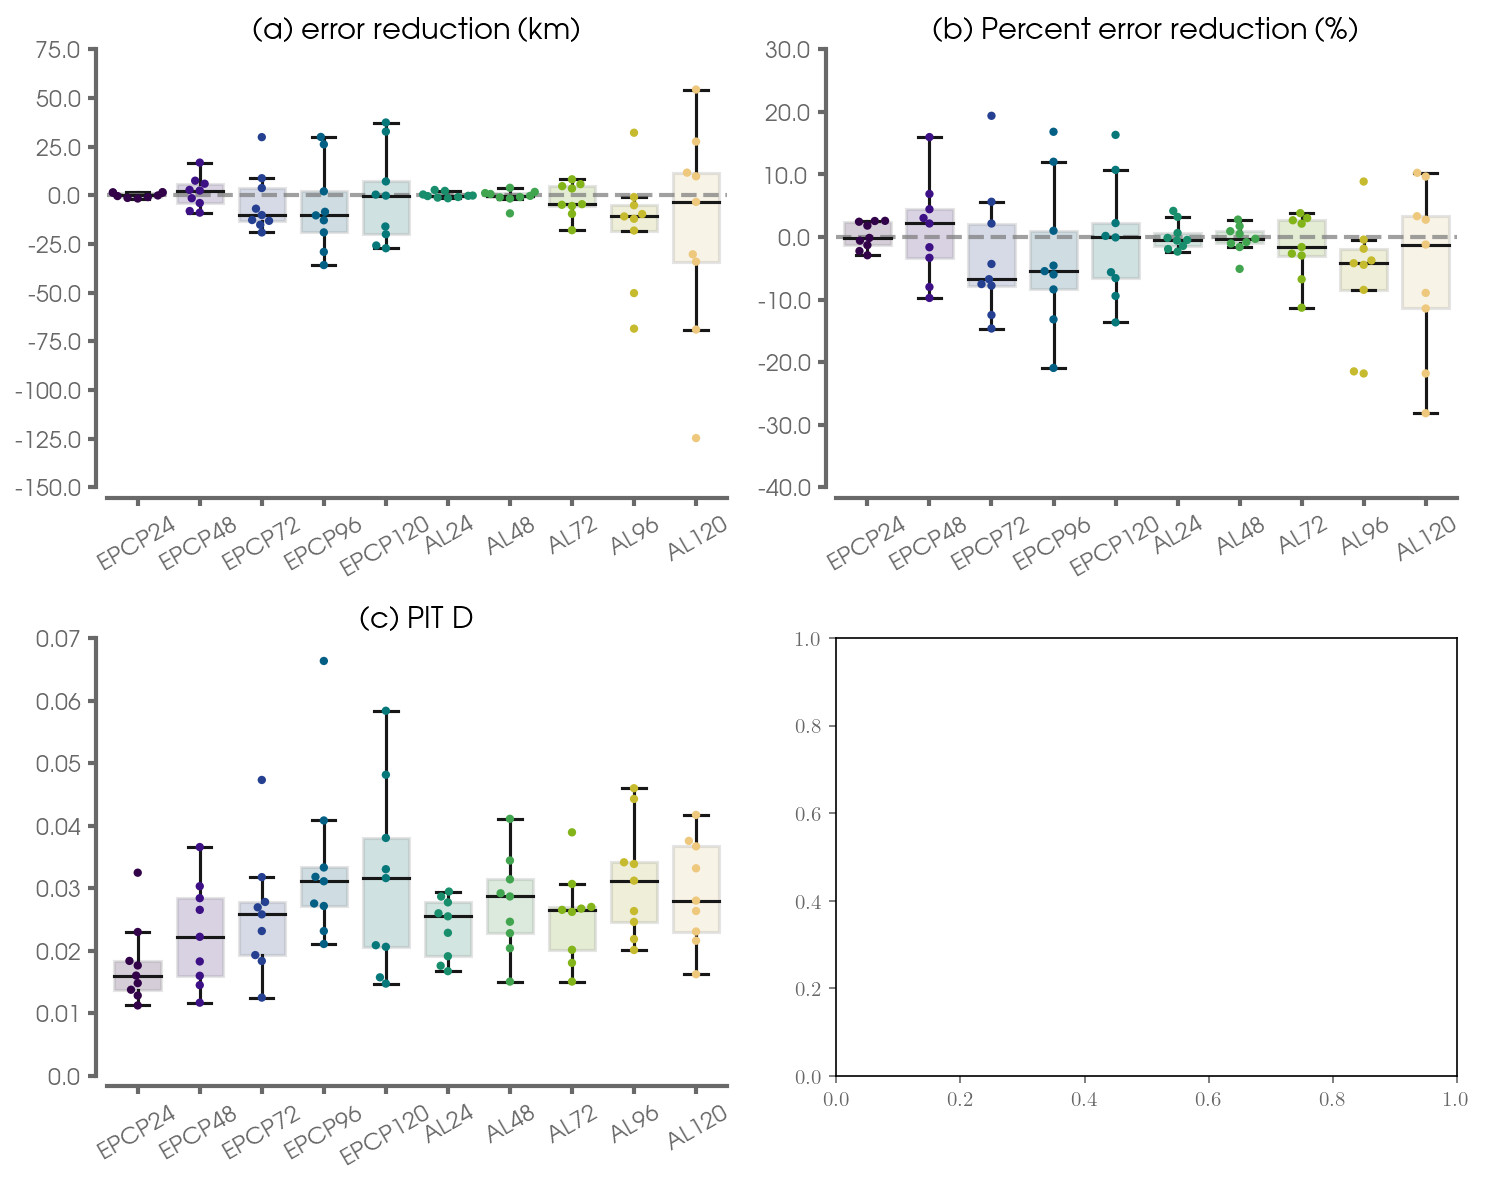

In [8]:
FS = 14

colors = cmr.take_cmap_colors('cmr.rainforest', 10, cmap_range=(0.15, 0.85), return_fmt='hex')
#plt.get_cmap('cmr.rainforest')#('#D95980','#A9C961','#C3B1E1','#C3B1E1','#351F27')
panel_letters = ('(a)','(b)','(c)','(d)')
x_axis_list = ("basin_lead",)#("basin_lead", "exp_name")

metric_data = ''
metric_list = ('mean_error_reduction_test',
               'perc_error_reduction_test',
               'pit_D_valtest',
              )
title_text = ('(a) error reduction (km)',
              '(b) Percent error reduction (\%)',              
              '(c) PIT D',
             )

for x_axis in x_axis_list:
    f, axs = plt.subplots(2, 2, figsize=(10,8),dpi=150)
    axs = axs.flatten()
    
    for imetric, metric in enumerate(metric_list):
        ax = axs[imetric]
        g1 = sns.boxplot(x=x_axis, 
                         y=metric, 
                         # hue="uncertainty_type",
                         data=df_metrics,
                         palette=colors,
                         width=.75,
                         dodge=True,                    
                         boxprops={'alpha':.2,
                                   'edgecolor': 'gray',
                                  },
                         fliersize=0,
                         ax=ax)
        g2 = sns.swarmplot(x=x_axis, 
                           y=metric, 
                           # hue="uncertainty_type",
                           palette=colors,
                           data=df_metrics, 
                           size=4,
                           dodge=True,
                           ax=ax)

        # ax.get_legend().remove()
        ax.set_title(title_text[imetric],
                     fontsize=FS,
                     color='k',
                    )
        
        
        if(metric.find('pit_D') > -1):
            ax.set_ylim(0,None)
        if(metric.find('reduction') > -1):
            ax.axhline(y=0.0,linewidth=2,linestyle='--',color='gray',alpha=.75)
        
        x_tick_labels = ax.get_xticklabels()
        y_tick_labels = ax.get_yticklabels()
        yticks = np.around(ax.get_yticks(),3)
        
        format_spines(ax)
        ax.set_xticklabels(x_tick_labels,rotation = 30,fontsize=FS*.8)
        ax.set_xlabel('')
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticks,fontsize=FS*.8)       
        ax.set_ylabel('')
        
        
    plt.tight_layout()    
    plt.savefig(FIGURE_PATH + 'all_metrics_boxplots.png', dpi=dpiFig, bbox_inches='tight')    
    plt.show()

In [11]:
df_metrics[df_metrics["basin_lead"]=="EPCP24"]

,uncertainty_type,network_seed,rng_seed,exp_name,basin_lead,testing_years,pit_D_test,pit_EDp_test,cons_error_test,mean_error_test,...,cons_error_val,mean_error_val,mean_error_reduction_val,perc_error_reduction_val,pit_D_valtest,pit_EDp_valtest,cons_error_valtest,mean_error_valtest,mean_error_reduction_valtest,perc_error_reduction_valtest
0,bivariate_normal,123,123,bivariate_normal_101_EPCP24,EPCP24,2013,0.030285,0.020089,68.382286,68.781192,...,64.014435,60.683128,3.331307,5.203993,0.017661,0.014586,66.317108,64.952320,1.364788,2.057973
0,bivariate_normal,123,123,bivariate_normal_101_EPCP24,EPCP24,2014,0.023460,0.015369,55.371620,54.022561,...,64.256866,61.676946,2.579920,4.015011,0.016044,0.012446,58.430225,56.657461,1.772764,3.033985
0,bivariate_normal,123,123,bivariate_normal_101_EPCP24,EPCP24,2015,0.043466,0.013019,70.318344,71.240481,...,60.310875,58.254827,2.056048,3.409084,0.032490,0.011096,67.580315,67.687634,-0.107319,-0.158803
0,bivariate_normal,123,123,bivariate_normal_101_EPCP24,EPCP24,2016,0.016097,0.015900,56.816586,58.476118,...,64.572273,61.876053,2.696220,4.175508,0.011267,0.012723,59.606396,59.699116,-0.092721,-0.155555
0,bivariate_normal,123,123,bivariate_normal_101_EPCP24,EPCP24,2017,0.020868,0.019570,59.665707,61.007473,...,63.339859,61.005402,2.334457,3.685605,0.012851,0.014384,61.354965,61.006521,0.348444,0.567916
0,bivariate_normal,345,345,bivariate_normal_101_EPCP24,EPCP24,2018,0.015350,0.013736,57.425259,57.510811,...,59.965546,57.996363,1.969183,3.283857,0.013778,0.011530,58.175716,57.654253,0.521463,0.896359
0,bivariate_normal,123,123,bivariate_normal_101_EPCP24,EPCP24,2019,0.026010,0.020000,73.311661,71.978826,...,63.603531,61.106841,2.496690,3.925395,0.018385,0.014552,68.743126,66.862598,1.880528,2.735587
0,bivariate_normal,123,123,bivariate_normal_101_EPCP24,EPCP24,2020,0.038609,0.022678,63.275501,61.659518,...,62.505226,58.819570,3.685656,5.896556,0.023009,0.015492,62.864689,60.144879,2.719810,4.326451
0,bivariate_normal,123,123,bivariate_normal_101_EPCP24,EPCP24,2021,0.028424,0.019612,58.954548,57.433508,...,62.885117,59.602379,3.282737,5.220214,0.014833,0.014400,60.765869,58.432988,2.332881,3.839131
